In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

pg_user = "postgres"
pg_pass = "postgres"
pg_host = "localhost"
pg_port = "5432"      
pg_db   = "geologia"
TABLE = 'v_gamma_1082_corr'

engine = create_engine(
    f"postgresql+psycopg2://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}"
)
folhas = [
    #"SB21",
    #"SB21_ZA",
    #"SB21_ZA_II1_NE",
    #"SB21_ZA_II2",
    #"SB21_XC_V4",
    #"SB21_XC_V3",
    # ...
]
lista_folhas_sql = ", ".join(f"'{f}'" for f in folhas)

sql_amostras = f"""
WITH folhas AS (
    SELECT
        codigo,
        escala,
        epsg,
        geom
    FROM carto.folhas_cartograficas
    WHERE codigo IN ({lista_folhas_sql})
)
SELECT
    -- identificação da folha cartográfica
    f.codigo AS folha_codigo,
    f.escala AS folha_escala,
    f.epsg   AS folha_epsg,

    -- atributos da amostra gama
    g.sample_id,
    g.survey_id,
    g.line_id,
    g.fiducial,
    g.date_local,
    g.time_local,

    -- coordenadas projetadas coerentes com a folha (recalculadas)
    ST_X(ST_Transform(g.geom, f.epsg)) AS x,
    ST_Y(ST_Transform(g.geom, f.epsg)) AS y,

    -- coordenadas geográficas originais
    g.lon, g.lat,

    g.gps_alt, g.baro_alt, g.altura,
    g.mdt, g.ctb, g.kb, g.ub, g.thb,
    g.uup, g.live_time, g.cosmico, g.temp,
    g.ctcor, g.kcor, g.ucor, g.thcor, g.ctexp,
    g.kperc, g.eu, g.eth,
    g.kperc_n, g.eu_n, g.eth_n, g.ctcor_n,
    g.thk_razao, g.uk_razao, g.uth_razao,
    g.geom AS geom_ponto,

    -- atributos da litologia 100k
    l.fid        AS lit_fid,
    l.id_unidade AS lit_id_unidade,
    l.sigla      AS lit_sigla,
    l.nome       AS lit_nome,
    l.legenda    AS lit_legenda,
    l.litotipos  AS lit_litotipos,
    l.escala     AS lit_escala,
    l.mapa       AS lit_mapa,
    l.eon_min, l.eon_max,
    l.era_min, l.era_max,
    l.sistema_mi, l.sistema_ma,
    l.epoca_min, l.epoca_max,
    l.geom       AS geom_lito

FROM geof.{TABLE} AS g
JOIN folhas AS f
  ON ST_Intersects(g.geom, f.geom)
LEFT JOIN litologia.litologia_100k AS l
  ON ST_Intersects(g.geom, l.geom);
"""

df_folha_lito = pd.read_sql(sql_amostras, engine)

sql_regions = f"""
WITH folhas_proj AS (
    SELECT
        codigo,
        ST_Envelope(ST_Transform(geom, epsg)) AS geom_proj
    FROM carto.folhas_cartograficas
    WHERE codigo IN ({lista_folhas_sql})
),
bbox_each AS (
    SELECT
        codigo,
        ST_XMin(geom_proj) AS x_min,
        ST_XMax(geom_proj) AS x_max,
        ST_YMin(geom_proj) AS y_min,
        ST_YMax(geom_proj) AS y_max
    FROM folhas_proj
),
bbox_total AS (
    SELECT
        'TOTAL'::text AS codigo,
        MIN(x_min) AS x_min,
        MAX(x_max) AS x_max,
        MIN(y_min) AS y_min,
        MAX(y_max) AS y_max
    FROM bbox_each
),
uniao AS (
    SELECT
        0 AS ord,
        codigo,
        x_min,
        x_max,
        y_min,
        y_max
    FROM bbox_total
    UNION ALL
    SELECT
        1 AS ord,
        codigo,
        x_min,
        x_max,
        y_min,
        y_max
    FROM bbox_each
)
SELECT
    codigo,
    x_min,
    x_max,
    y_min,
    y_max
FROM uniao
ORDER BY ord, codigo;
"""

df_regions = pd.read_sql(sql_regions, engine)

regions = [
    [
        np.float64(row["x_min"]),
        np.float64(row["x_max"]),
        np.float64(row["y_min"]),
        np.float64(row["y_max"]),
    ]
    for _, row in df_regions.iterrows()
]

codigos = df_regions["codigo"].tolist()      # ['TOTAL', 'SB21_ZA_II1_NE', ...]
region_total = regions[0]                    # bbox total
regions_por_folha = dict(zip(codigos[1:], regions[1:]))

# Objetos finais:
# - df_folha_lito: DataFrame com amostras + litologia + folha_codigo
# - region_total: [x_min_total, x_max_total, y_min_total, y_max_total]
# - regions_por_folha[folha_codigo]: region de cada folha selecionada
# Precisa verificar valores negativos

In [2]:
df_folha_lito.head(5)

,folha_codigo,folha_escala,folha_epsg,sample_id,survey_id,line_id,fiducial,date_local,time_local,x,...,lit_mapa,eon_min,eon_max,era_min,era_max,sistema_mi,sistema_ma,epoca_min,epoca_max,geom_lito
0,SB21_ZA_II1_NE,25k,32721,1103913,1,342,9214.0,2009-08-30,13:03:11,569434.877930,...,Carta geológica da folha São Domingos,Proterozóico,Proterozóico,Paleoproterozóico,Paleoproterozóico,Orosiriano,Orosiriano,Furongiano,Furongiano,0106000020E61000000100000001030000000100000046...
1,SB21_ZA_II1_NE,25k,32721,1103914,1,342,9232.0,2009-08-30,13:03:29,569443.770135,...,Carta geológica da folha São Domingos,Proterozóico,Proterozóico,Paleoproterozóico,Paleoproterozóico,Orosiriano,Orosiriano,Furongiano,Furongiano,0106000020E61000000100000001030000000100000046...
2,SB21_ZA_II1_NE,25k,32721,1103915,1,342,9249.0,2009-08-30,13:03:46,569459.992604,...,Carta geológica da folha São Domingos,Proterozóico,Proterozóico,Paleoproterozóico,Paleoproterozóico,Orosiriano,Orosiriano,Furongiano,Furongiano,0106000020E61000000100000001030000000100000046...
3,SB21_ZA_II1_NE,25k,32721,1103916,1,342,9254.0,2009-08-30,13:03:51,569456.930436,...,Carta geológica da folha São Domingos,Proterozóico,Proterozóico,Paleoproterozóico,Paleoproterozóico,Orosiriano,Orosiriano,Furongiano,Furongiano,0106000020E61000000100000001030000000100000046...
4,SB21_ZA_II1_NE,25k,32721,1103917,1,342,9259.0,2009-08-30,13:03:56,569454.835706,...,Carta geológica da folha São Domingos,Proterozóico,Proterozóico,Paleoproterozóico,Paleoproterozóico,Orosiriano,Orosiriano,Furongiano,Furongiano,0106000020E61000000100000001030000000100000046...


In [3]:
df_folha_lito.describe().T

,count,mean,std,min,25%,50%,75%,max
folha_epsg,4993.0,3.272100e+04,0.000000,3.272100e+04,3.272100e+04,3.272100e+04,3.272100e+04,3.272100e+04
sample_id,4993.0,7.231277e+05,401116.041567,6.035700e+04,4.096500e+05,7.576230e+05,1.104185e+06,1.373299e+06
survey_id,4993.0,1.000000e+00,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
line_id,4993.0,3.698187e+02,15.836966,3.420000e+02,3.570000e+02,3.710000e+02,3.850000e+02,3.940000e+02
fiducial,4993.0,1.022999e+04,3887.814890,2.903000e+03,9.184000e+03,1.004900e+04,1.128800e+04,1.697700e+04
x,4993.0,5.762381e+05,4054.509560,5.694028e+05,5.729178e+05,5.764277e+05,5.799198e+05,5.829493e+05
y,4993.0,9.329834e+06,3995.935677,9.322927e+06,9.326359e+06,9.329847e+06,9.333294e+06,9.336748e+06
lon,4993.0,-5.631106e+01,0.036638,-5.637288e+01,-5.634103e+01,-5.630934e+01,-5.627783e+01,-5.625039e+01
lat,4993.0,-6.062534e+00,0.036146,-6.124975e+00,-6.093925e+00,-6.062411e+00,-6.031206e+00,-6.000029e+00
gps_alt,4993.0,2.719175e+02,31.350110,2.102800e+02,2.524300e+02,2.659700e+02,2.859200e+02,4.393400e+02


In [4]:
cols_geof = [ "mdt", "ctcor", "kperc", "eu", "eth", "thk_razao", "uk_razao", "uth_razao"]

print(f' N. Amostras: {df_folha_lito.shape[0]}')
print(f' N. Colunas: {df_folha_lito.shape[1]}')
print('')
print('Valores nulos: ')
print(f'{df_folha_lito[cols_geof].isna().sum()}')

lit_nome = df_folha_lito.lit_nome.unique()
lit_sigla = df_folha_lito.lit_sigla.unique()
lit_id = df_folha_lito.lit_id_unidade.unique()
lit_fid = df_folha_lito.lit_fid.unique()
print('')

print(f' Litologias na carta: {lit_nome}\n')
print(f'ID unidade litológica: {lit_sigla}\n')
print(lit_fid)

 N. Amostras: 4993
 N. Colunas: 58

Valores nulos: 
mdt          0
ctcor        0
kperc        0
eu           0
eth          0
thk_razao    0
uk_razao     0
uth_razao    0
dtype: int64

 Litologias na carta: ['Complexo Cuiú-Cuiú' 'Depósitos aluvionares' 'Suíte Creporizão'
 'Suíte Maloquinha']

ID unidade litológica: ['PP3cc' 'Q2a' 'PP3_gamma_cz' 'PP3_gamma_ml']

[  358 15284  7726 29990 44819  7730 37349 37352]


In [5]:
cols_geof_n = [ "mdt", "ctcor_n", "ctcor", "kperc_n", "kperc", "eu_n", "eu", "eth_n", "eth", "thk_razao", "uk_razao", "uth_razao"]

df_folha_lito[cols_geof_n].describe(percentiles=[0.005,0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.995]).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,90%,99%,99.5%,max
mdt,4993.0,157.671318,25.989996,107.100,111.70240,113.16920,126.5800,141.080,155.950,170.360,187.1740,237.45640,256.93280,357.210
ctcor_n,4993.0,932.617217,233.237856,349.358,504.45488,522.98900,649.2284,750.648,905.371,1094.511,1257.5096,1512.24992,1572.04916,1847.369
ctcor,4993.0,932.617217,233.237856,349.358,504.45488,522.98900,649.2284,750.648,905.371,1094.511,1257.5096,1512.24992,1572.04916,1847.369
kperc_n,4993.0,0.330793,0.192848,0.000,0.01796,0.02892,0.1150,0.196,0.303,0.429,0.5770,0.96432,1.05708,1.578
kperc,4993.0,0.329226,0.195639,-0.228,-0.05404,-0.02600,0.1150,0.196,0.303,0.429,0.5770,0.96432,1.05708,1.578
eu_n,4993.0,1.068313,0.707065,0.000,0.03000,0.05184,0.1582,0.524,0.991,1.497,1.9682,3.10472,3.37968,6.131
eu,4993.0,1.044184,0.746384,-1.330,-0.64328,-0.46608,0.1582,0.524,0.991,1.497,1.9682,3.10472,3.37968,6.131
eth_n,4993.0,12.399644,3.819276,4.907,6.00668,6.38212,8.1766,9.595,11.595,14.704,17.6338,23.72968,25.25640,30.908
eth,4993.0,12.399644,3.819276,4.907,6.00668,6.38212,8.1766,9.595,11.595,14.704,17.6338,23.72968,25.25640,30.908
thk_razao,4993.0,54.107532,62.559441,0.000,0.00000,0.00000,16.9634,25.151,38.542,58.989,98.1338,331.63616,452.56036,1038.490


In [6]:
# Tratar dados negativos

In [7]:
# Colunas radiométricas de interesse (contagens / concentrações)
cols_rad = ["kperc", "eu", "eth"]

for col in cols_rad:
    serie = df_folha_lito[col].astype(float)
    # diagnóstico rápido
    n_neg = (serie < 0).sum()
    print(f"{col}: min={serie.min():.6f}, n_negativos={n_neg}")
    pos = serie[serie > 0]
    mean_pos = pos.mean()
    limiar = mean_pos / 10.0
    #mean_ = serie.mean() 
    #limiar = mean_ / 10.0

    # cria coluna corrigida, sem sobrescrever o original
    col_thr = col + "_thr"
    df_folha_lito[col_thr] = serie.copy()

    # aplica o threshold: QUALQUER valor < limiar vira limiar
    mask_low = serie < limiar
    df_folha_lito.loc[mask_low, col_thr] = limiar

    print(
        f"{col}: mean_pos={mean_pos:.6f}, limiar={limiar:.6f}, ",
        f"n_valores_ajustados={mask_low.sum()}")

kperc: min=-0.228000, n_negativos=94
kperc: mean_pos=0.336539, limiar=0.033654,  n_valores_ajustados=155
eu: min=-1.330000, n_negativos=305
eu: mean_pos=1.129337, limiar=0.112934,  n_valores_ajustados=442
eth: min=4.907000, n_negativos=0
eth: mean_pos=12.399644, limiar=1.239964,  n_valores_ajustados=0


In [8]:
# print(df_folha_lito.columns)
'''
Index(['folha_codigo', 'folha_escala', 'folha_epsg', 'sample_id', 'survey_id',
       'line_id', 'fiducial', 'date_local', 'time_local', 'x', 'y', 'lon',
       'lat', 'gps_alt', 'baro_alt', 'altura', 'mdt', 'ctb', 'kb', 'ub', 'thb',
       'uup', 'live_time', 'cosmico', 'temp', 'ctcor', 'kcor', 'ucor', 'thcor',
       'ctexp', 'kperc', 'eu', 'eth', 'thk_razao', 'uk_razao', 'uth_razao',
       'geom_ponto', 'lit_fid', 'lit_id_unidade', 'lit_sigla', 'lit_nome',
       'lit_legenda', 'lit_litotipos', 'lit_escala', 'lit_mapa', 'eon_min',
       'eon_max', 'era_min', 'era_max', 'sistema_mi', 'sistema_ma',
       'epoca_min', 'epoca_max', 'geom_lito', 'kperc_thr', 'eu_thr',
       'eth_thr'],
      dtype='object')

'''

df_folha_lito['line_id'].unique()



array([342, 344, 347, 349, 351, 353, 355, 357, 359, 361, 363, 365, 367,
       369, 371, 373, 375, 377, 379, 381, 383, 385, 387, 389, 390, 391,
       392, 394])

In [9]:
df_folha_lito[cols_geof_n+ ['eu_thr', 'kperc_thr']].describe(percentiles=[0.005,0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.995]).T

,count,mean,std,min,0.5%,1%,10%,25%,50%,75%,90%,99%,99.5%,max
mdt,4993.0,157.671318,25.989996,107.100000,111.702400,113.169200,126.5800,141.080,155.950,170.360,187.1740,237.45640,256.93280,357.210
ctcor_n,4993.0,932.617217,233.237856,349.358000,504.454880,522.989000,649.2284,750.648,905.371,1094.511,1257.5096,1512.24992,1572.04916,1847.369
ctcor,4993.0,932.617217,233.237856,349.358000,504.454880,522.989000,649.2284,750.648,905.371,1094.511,1257.5096,1512.24992,1572.04916,1847.369
kperc_n,4993.0,0.330793,0.192848,0.000000,0.017960,0.028920,0.1150,0.196,0.303,0.429,0.5770,0.96432,1.05708,1.578
kperc,4993.0,0.329226,0.195639,-0.228000,-0.054040,-0.026000,0.1150,0.196,0.303,0.429,0.5770,0.96432,1.05708,1.578
eu_n,4993.0,1.068313,0.707065,0.000000,0.030000,0.051840,0.1582,0.524,0.991,1.497,1.9682,3.10472,3.37968,6.131
eu,4993.0,1.044184,0.746384,-1.330000,-0.643280,-0.466080,0.1582,0.524,0.991,1.497,1.9682,3.10472,3.37968,6.131
eth_n,4993.0,12.399644,3.819276,4.907000,6.006680,6.382120,8.1766,9.595,11.595,14.704,17.6338,23.72968,25.25640,30.908
eth,4993.0,12.399644,3.819276,4.907000,6.006680,6.382120,8.1766,9.595,11.595,14.704,17.6338,23.72968,25.25640,30.908
thk_razao,4993.0,54.107532,62.559441,0.000000,0.000000,0.000000,16.9634,25.151,38.542,58.989,98.1338,331.63616,452.56036,1038.490


## Trend

In [10]:
# Coordenadas da folha (df_folha_lito já filtrado)
x = df_folha_lito["x"].values
y = df_folha_lito["y"].values

coords = (x, y)

import verde as vd
dist = vd.median_distance(coords, k_nearest=25)  # em metros
d_med = np.median(dist)
print(d_med, "m")

490.6610178506092 m


In [11]:
coordinates = coords
data = df_folha_lito

In [12]:
cols_geof_n = cols_geof_n+['kperc_thr', 'eu_thr']

In [13]:
data[cols_geof_n].describe().T

,count,mean,std,min,25%,50%,75%,max
mdt,4993.0,157.671318,25.989996,107.100000,141.080,155.950,170.360,357.210
ctcor_n,4993.0,932.617217,233.237856,349.358000,750.648,905.371,1094.511,1847.369
ctcor,4993.0,932.617217,233.237856,349.358000,750.648,905.371,1094.511,1847.369
kperc_n,4993.0,0.330793,0.192848,0.000000,0.196,0.303,0.429,1.578
kperc,4993.0,0.329226,0.195639,-0.228000,0.196,0.303,0.429,1.578
eu_n,4993.0,1.068313,0.707065,0.000000,0.524,0.991,1.497,6.131
eu,4993.0,1.044184,0.746384,-1.330000,0.524,0.991,1.497,6.131
eth_n,4993.0,12.399644,3.819276,4.907000,9.595,11.595,14.704,30.908
eth,4993.0,12.399644,3.819276,4.907000,9.595,11.595,14.704,30.908
thk_razao,4993.0,54.107532,62.559441,0.000000,25.151,38.542,58.989,1038.490


In [17]:
import matplotlib.pyplot as plt

VAR = 'eu'
trend = vd.Trend(degree=3).fit(coordinates, data[VAR])
print(trend.coef_)

[ 4.80338918e+02 -1.45044277e+02  8.97236258e+00 -3.44729888e-06
  3.15234970e-05 -1.93685405e-06  9.00247039e-13  2.02796323e-13
 -1.70219668e-12  1.04309270e-13]


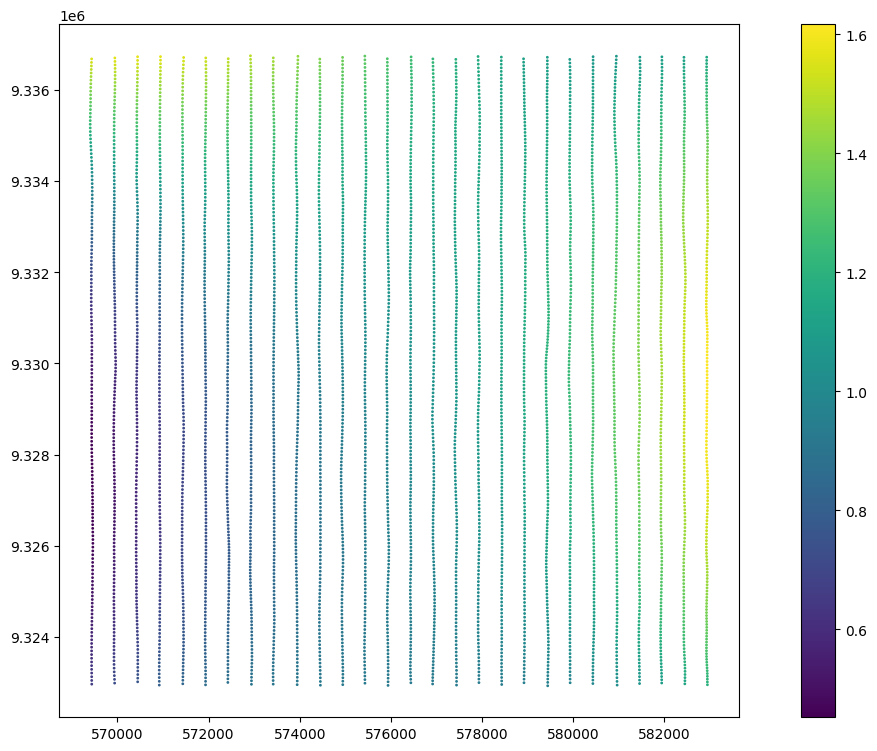

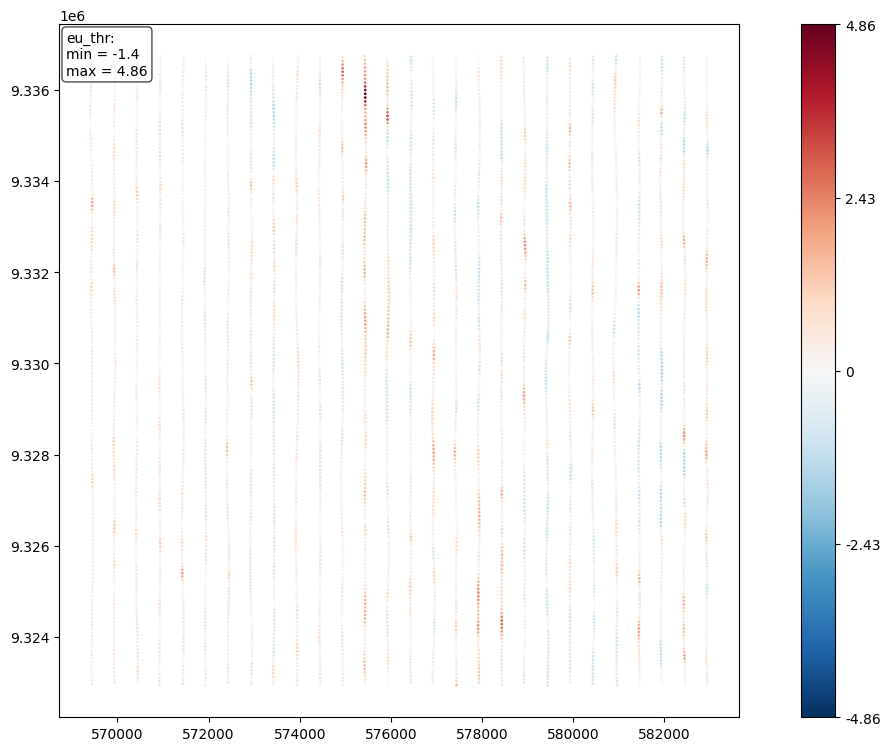

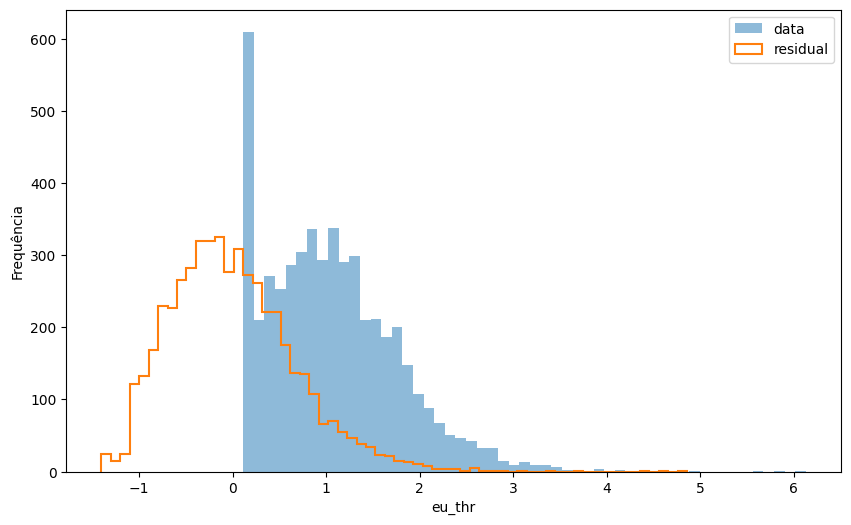

In [18]:
VAR = 'eu_thr'
trend = vd.Trend(degree=3)
trend.fit(coordinates, data[VAR])
regional = trend.predict(coordinates)
plt.figure(figsize=(16,9))
plt.scatter(coordinates[0], coordinates[1], c=regional, s=1, vmin=regional.min(), vmax=regional.max())
plt.axis("scaled")
plt.colorbar()
residual = data[VAR] - regional
scale = vd.maxabs(residual)
vmin, vmax = -scale, scale

plt.figure(figsize=(16, 9))
ax = plt.gca()

sc = ax.scatter(
    coordinates[0], coordinates[1], c=residual,
    s=1, cmap="RdBu_r", vmin=vmin, vmax=vmax,
)
ax.set_aspect("equal")

cbar = plt.colorbar(sc)
n_ticks = 5
ticks = np.linspace(vmin, vmax, n_ticks)
cbar.set_ticks(ticks)
cbar.ax.set_yticklabels([f"{t:.3g}" for t in ticks])

# valores mínimo e máximo "reais" do residual (sem simetrizar, se quiser)
min_val = np.nanmin(residual)
max_val = np.nanmax(residual)
txt = f"{VAR}:\nmin = {min_val:.3g}\nmax = {max_val:.3g}"
ax.text(
    0.01, 0.99, txt,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)

plt.figure(figsize=(10, 6))

plt.hist(data[VAR], bins='auto', alpha=0.5, label='data')

plt.hist(
    residual,
    bins='auto',
    histtype='step',   # só contorno
    linewidth=1.5,
    label='residual'
)

plt.legend()
plt.xlabel(VAR)
plt.ylabel("Frequência")
plt.show()


[ 4.58540789e+02 -1.38712999e+02  8.57827401e+00 -2.60026774e-06
  3.00614525e-05 -1.84913039e-06  8.57888967e-13  1.19867589e-13
 -1.61871133e-12  9.94441967e-14]


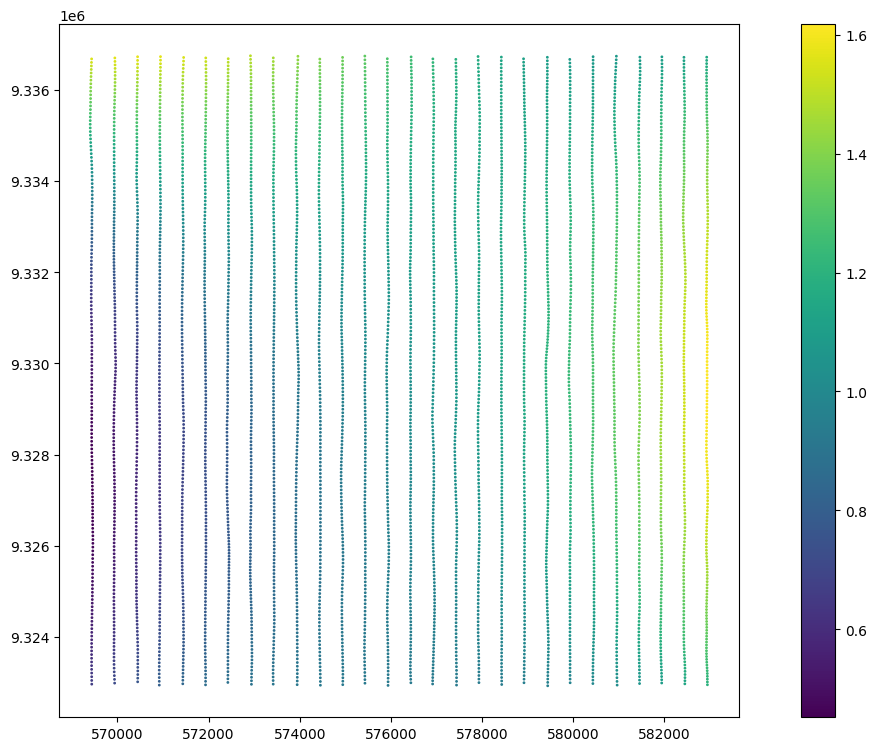

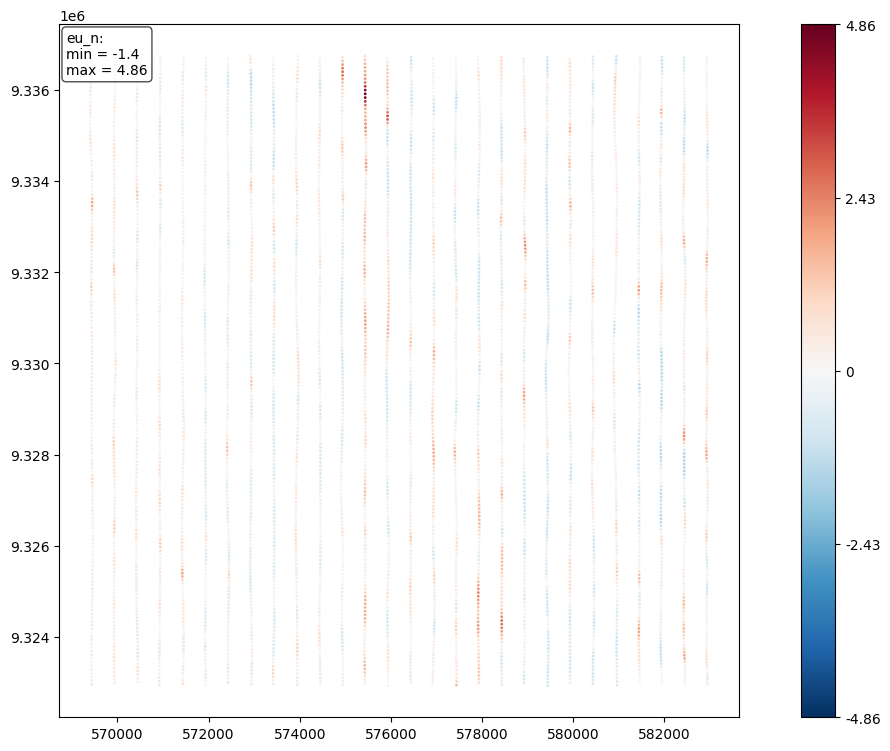

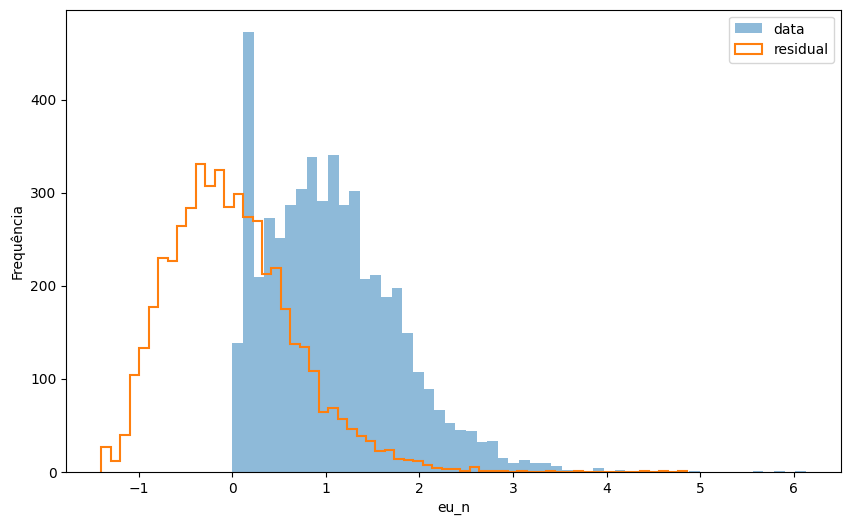

In [19]:
VAR = 'eu_n'
trend = vd.Trend(degree=3).fit(coordinates, data[VAR])
print(trend.coef_)

trend = vd.Trend(degree=3)
trend.fit(coordinates, data[VAR])
regional = trend.predict(coordinates)
plt.figure(figsize=(16,9))
plt.scatter(coordinates[0], coordinates[1], c=regional, s=1, vmin=regional.min(), vmax=regional.max())
plt.axis("scaled")
plt.colorbar()
residual = data[VAR] - regional
scale = vd.maxabs(residual)
vmin, vmax = -scale, scale

plt.figure(figsize=(16, 9))
ax = plt.gca()

sc = ax.scatter(
    coordinates[0], coordinates[1], c=residual,
    s=1, cmap="RdBu_r", vmin=vmin, vmax=vmax,
)
ax.set_aspect("equal")

cbar = plt.colorbar(sc)
n_ticks = 5
ticks = np.linspace(vmin, vmax, n_ticks)
cbar.set_ticks(ticks)
cbar.ax.set_yticklabels([f"{t:.3g}" for t in ticks])

# valores mínimo e máximo "reais" do residual (sem simetrizar, se quiser)
min_val = np.nanmin(residual)
max_val = np.nanmax(residual)
txt = f"{VAR}:\nmin = {min_val:.3g}\nmax = {max_val:.3g}"
ax.text(
    0.01, 0.99, txt,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)
plt.figure(figsize=(10, 6))

plt.hist(data[VAR], bins='auto', alpha=0.5, label='data')

plt.hist(
    residual,
    bins='auto',
    histtype='step',   # só contorno
    linewidth=1.5,
    label='residual'
)
plt.legend()
plt.xlabel(VAR)
plt.ylabel("Frequência")
plt.show()


[ 1.29034921e+05  4.73564724e-02 -3.06147937e-02  9.03469723e-10
 -5.18286685e-09  1.80218432e-09]


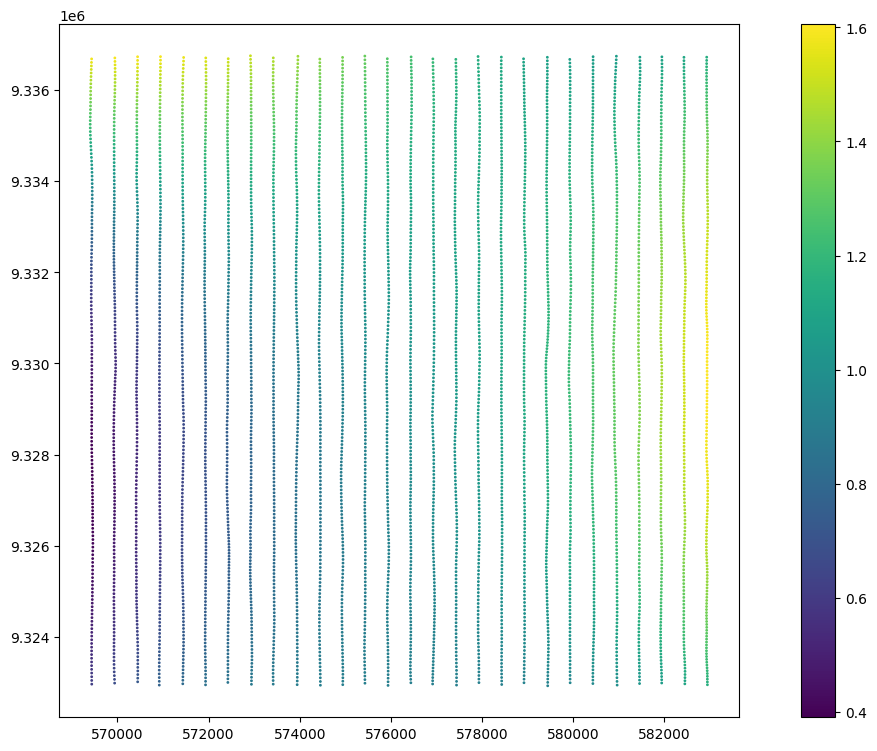

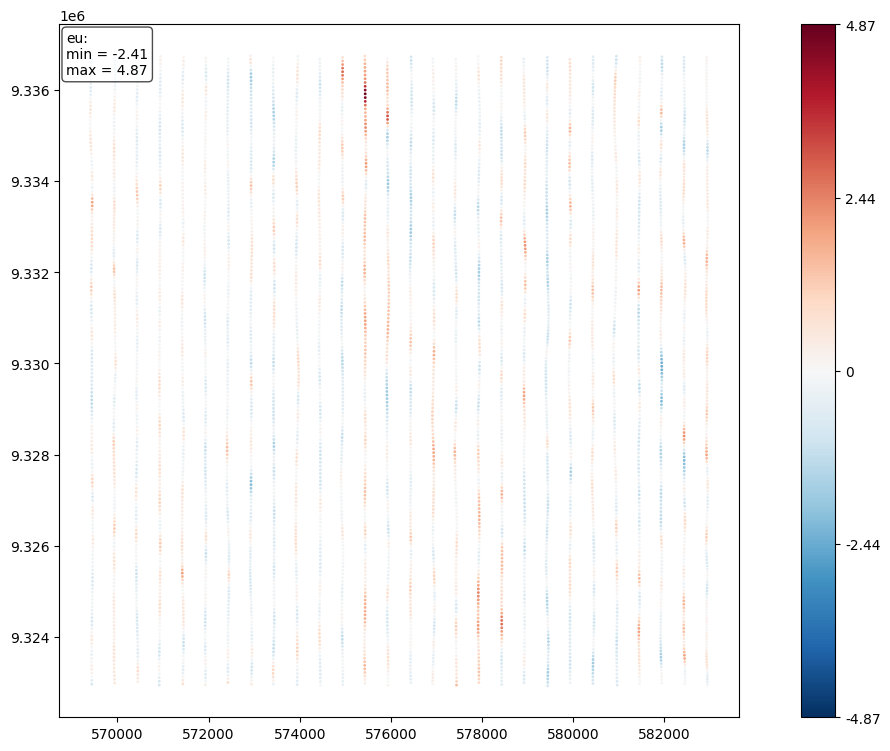

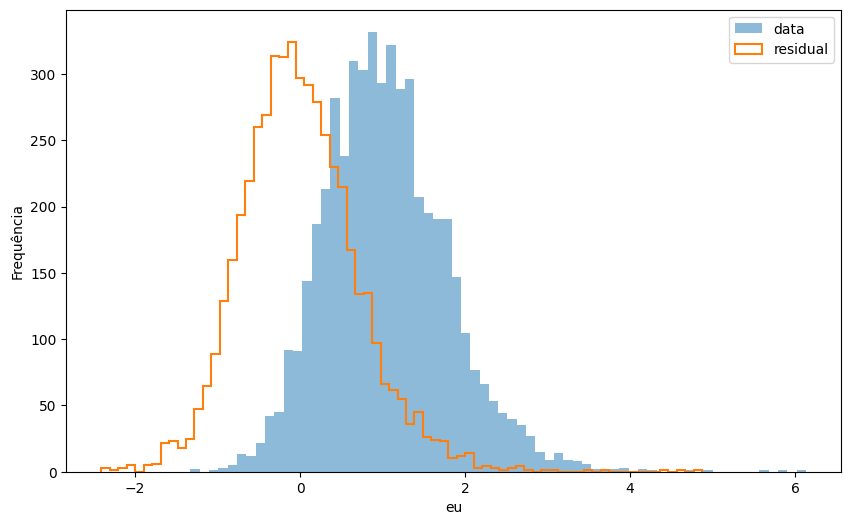

In [20]:
VAR = 'eu'
trend = vd.Trend(degree=2).fit(coordinates, data[VAR])
print(trend.coef_)

trend = vd.Trend(degree=3)
trend.fit(coordinates, data[VAR])
regional = trend.predict(coordinates)
plt.figure(figsize=(16,9))
plt.scatter(coordinates[0], coordinates[1], c=regional, s=1, vmin=regional.min(), vmax=regional.max())
plt.axis("scaled")
plt.colorbar()
residual = data[VAR] - regional
scale = vd.maxabs(residual)
vmin, vmax = -scale, scale

plt.figure(figsize=(16, 9))
ax = plt.gca()

sc = ax.scatter(
    coordinates[0], coordinates[1], c=residual,
    s=1, cmap="RdBu_r", vmin=vmin, vmax=vmax,
)
ax.set_aspect("equal")

cbar = plt.colorbar(sc)
n_ticks = 5
ticks = np.linspace(vmin, vmax, n_ticks)
cbar.set_ticks(ticks)
cbar.ax.set_yticklabels([f"{t:.3g}" for t in ticks])

# valores mínimo e máximo "reais" do residual (sem simetrizar, se quiser)
min_val = np.nanmin(residual)
max_val = np.nanmax(residual)
txt = f"{VAR}:\nmin = {min_val:.3g}\nmax = {max_val:.3g}"
ax.text(
    0.01, 0.99, txt,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
)
plt.figure(figsize=(10, 6))

plt.hist(data[VAR], bins='auto', alpha=0.5, label='data')

plt.hist(
    residual,
    bins='auto',
    histtype='step',   # só contorno
    linewidth=1.5,
    label='residual'
)
plt.legend()
plt.xlabel(VAR)
plt.ylabel("Frequência")
plt.show()


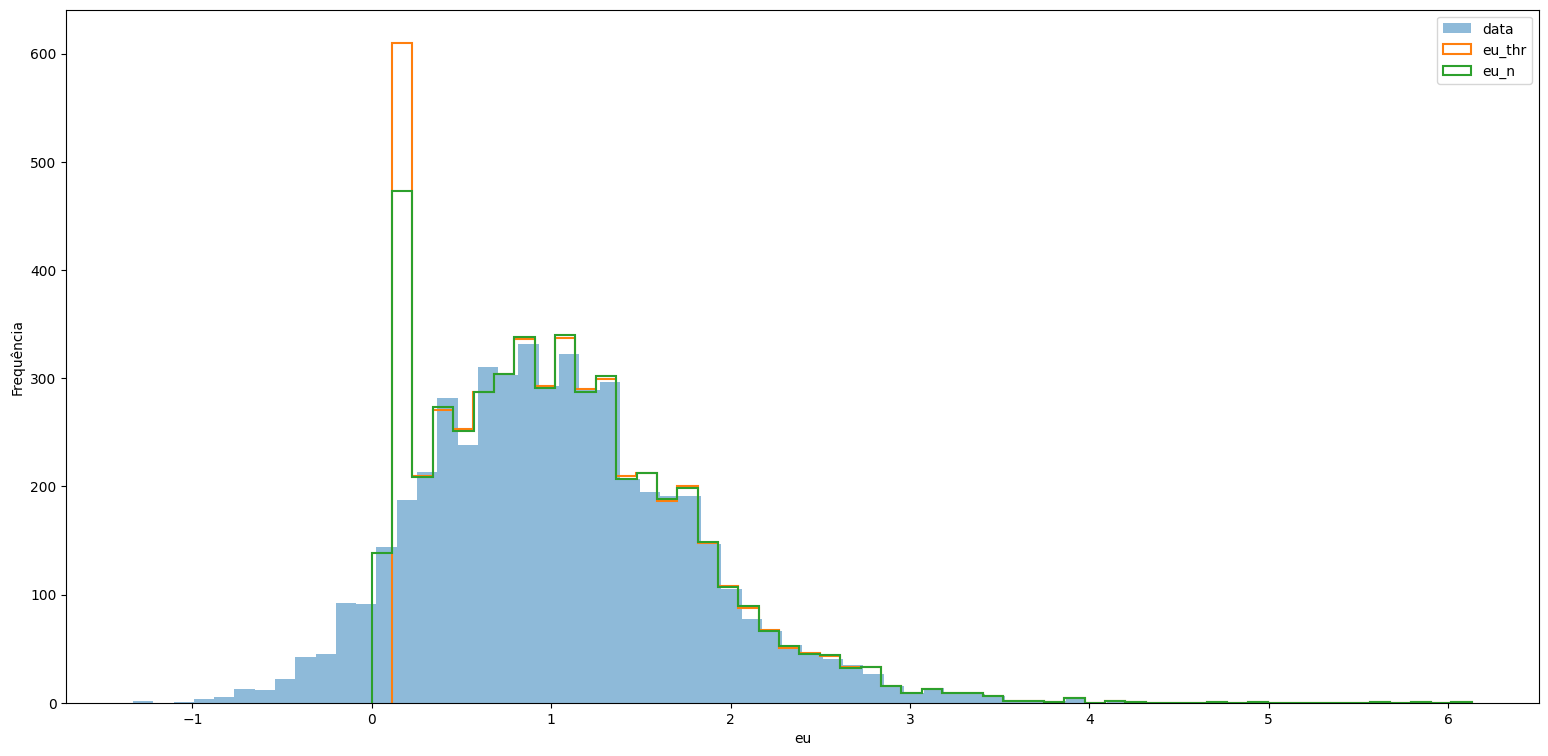

In [22]:
plt.figure(figsize=(19, 9))

plt.hist(
    data['eu'],
    bins='auto',
    alpha=0.5,
    label='data'
)

plt.hist(
    data['eu_thr'],
    bins='auto',
    histtype='step',
    linewidth=1.5,
    label='eu_thr'
)


plt.hist(
    data['eu_n'],
    bins='auto',
    histtype='step',
    linewidth=1.5,
    label='eu_n'
)

plt.legend()
plt.xlabel(VAR)
plt.ylabel("Frequência")
plt.show()


In [ ]:
plt.figure(figsize=(19, 9))

plt.hist(
    data['eu'],
    bins='auto',
    alpha=0.5,
    label='data'
)

plt.hist(
    data['eu_thr'],
    bins='auto',
    histtype='step',
    linewidth=1.5,
    label='eu_thr'
)


plt.hist(
    data['eu_n'],
    bins='auto',
    histtype='step',
    linewidth=1.5,
    label='eu_n'
)

plt.legend()
plt.xlabel(VAR)
plt.ylabel("Frequência")
plt.show()


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd

vars_eu = ["eu", "eu_thr", "eu_n"]

trends = {}       # guarda os objetos Trend
regionals = {}    # guarda o componente regional (polinômio)
residuals = {}    # guarda os resíduos
scores = {}       # R² do Trend para cada série

for var in vars_eu:
    y = data[var].values

    trend = vd.Trend(degree=0).fit(coordinates, y)
    trends[var] = trend

    regional = trend.predict(coordinates)
    regionals[var] = regional

    resid = y - regional
    residuals[var] = resid

    scores[var] = trend.score(coordinates, y)  # R² do ajuste

# Opcional: jogar os resíduos no DataFrame para uso posterior
for var in vars_eu:
    data[f"{var}_res"] = residuals[var]

print("Coeficientes e R² do Trend(degree=3):")
for var in vars_eu:
    print(f"{var}: coef_={trends[var].coef_}, R²={scores[var]:.4f}")


Coeficientes e R² do Trend(degree=3):
eu: coef_=[1.04418446], R²=0.0000
eu_thr: coef_=[1.06842273], R²=0.0000
eu_n: coef_=[1.06831345], R²=0.0000


/tmp/ipykernel_171960/715647363.py:24: FutureWarning: The default scoring will change from R² to negative root mean squared error (RMSE) in Verde 2.0.0. This may change model selection results slightly.
  scores[var] = trend.score(coordinates, y)  # R² do ajuste
/tmp/ipykernel_171960/715647363.py:24: FutureWarning: The default scoring will change from R² to negative root mean squared error (RMSE) in Verde 2.0.0. This may change model selection results slightly.
  scores[var] = trend.score(coordinates, y)  # R² do ajuste
/tmp/ipykernel_171960/715647363.py:24: FutureWarning: The default scoring will change from R² to negative root mean squared error (RMSE) in Verde 2.0.0. This may change model selection results slightly.
  scores[var] = trend.score(coordinates, y)  # R² do ajuste


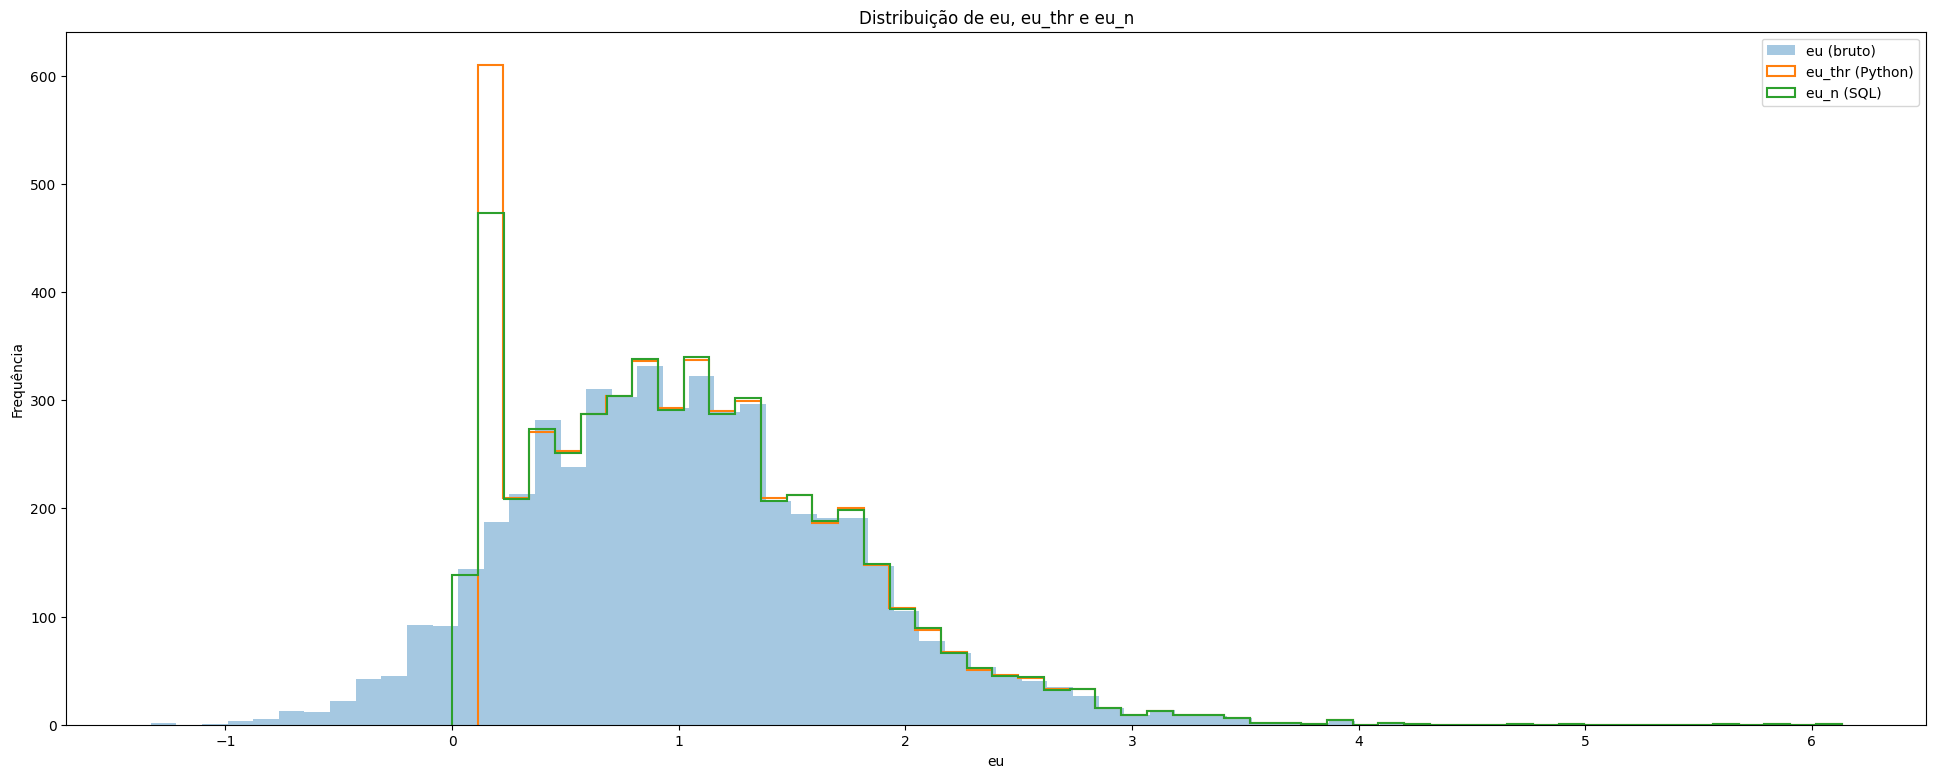

In [35]:
plt.figure(figsize=(24, 9))

plt.hist(
    data["eu"],
    bins="auto",
    alpha=0.4,
    label="eu (bruto)"
)

plt.hist(
    data["eu_thr"],
    bins="auto",
    histtype="step",
    linewidth=1.5,
    label="eu_thr (Python)"
)

plt.hist(
    data["eu_n"],
    bins="auto",
    histtype="step",
    linewidth=1.5,
    label="eu_n (SQL)"
)

plt.legend()
plt.xlabel("eu")
plt.ylabel("Frequência")
plt.title("Distribuição de eu, eu_thr e eu_n")
plt.show()


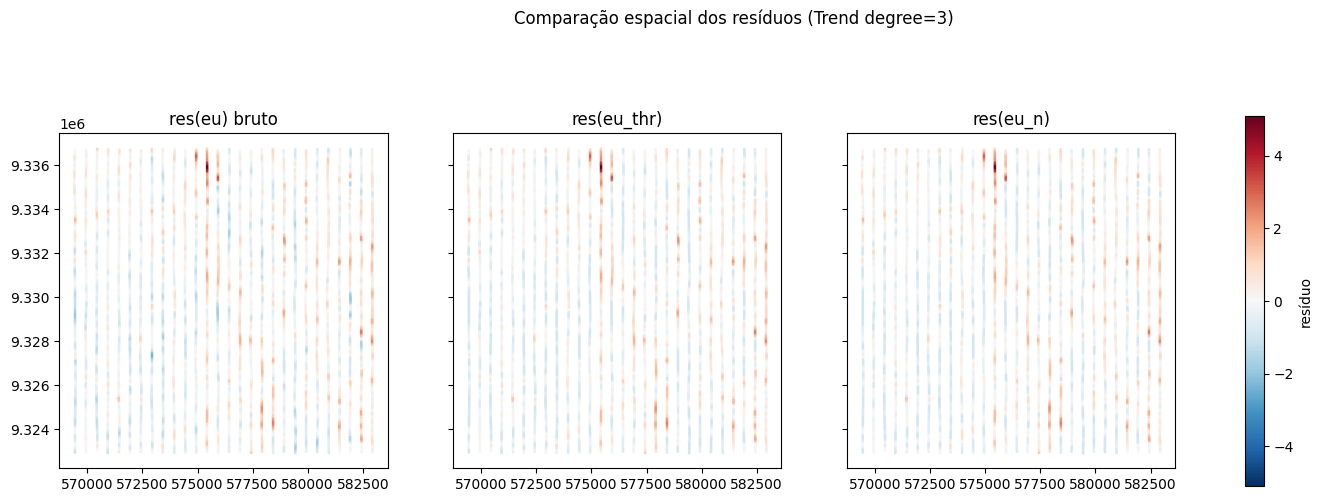

In [28]:
# 1) calcular vmin/vmax global dos resíduos para escala de cor comum
all_res = np.concatenate([residuals[var] for var in vars_eu])
scale = np.nanmax(np.abs(all_res))
vmin, vmax = -scale, scale

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

for ax, var, title in zip(
    axes,
    ["eu", "eu_thr", "eu_n"],
    ["res(eu) bruto", "res(eu_thr)", "res(eu_n)"]
):
    sc = ax.scatter(
        coordinates[0],
        coordinates[1],
        c=residuals[var],
        s=1,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_aspect("equal")
    ax.set_title(title)

fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8, label="resíduo")
plt.suptitle("Comparação espacial dos resíduos (Trend degree=3)")
plt.show()


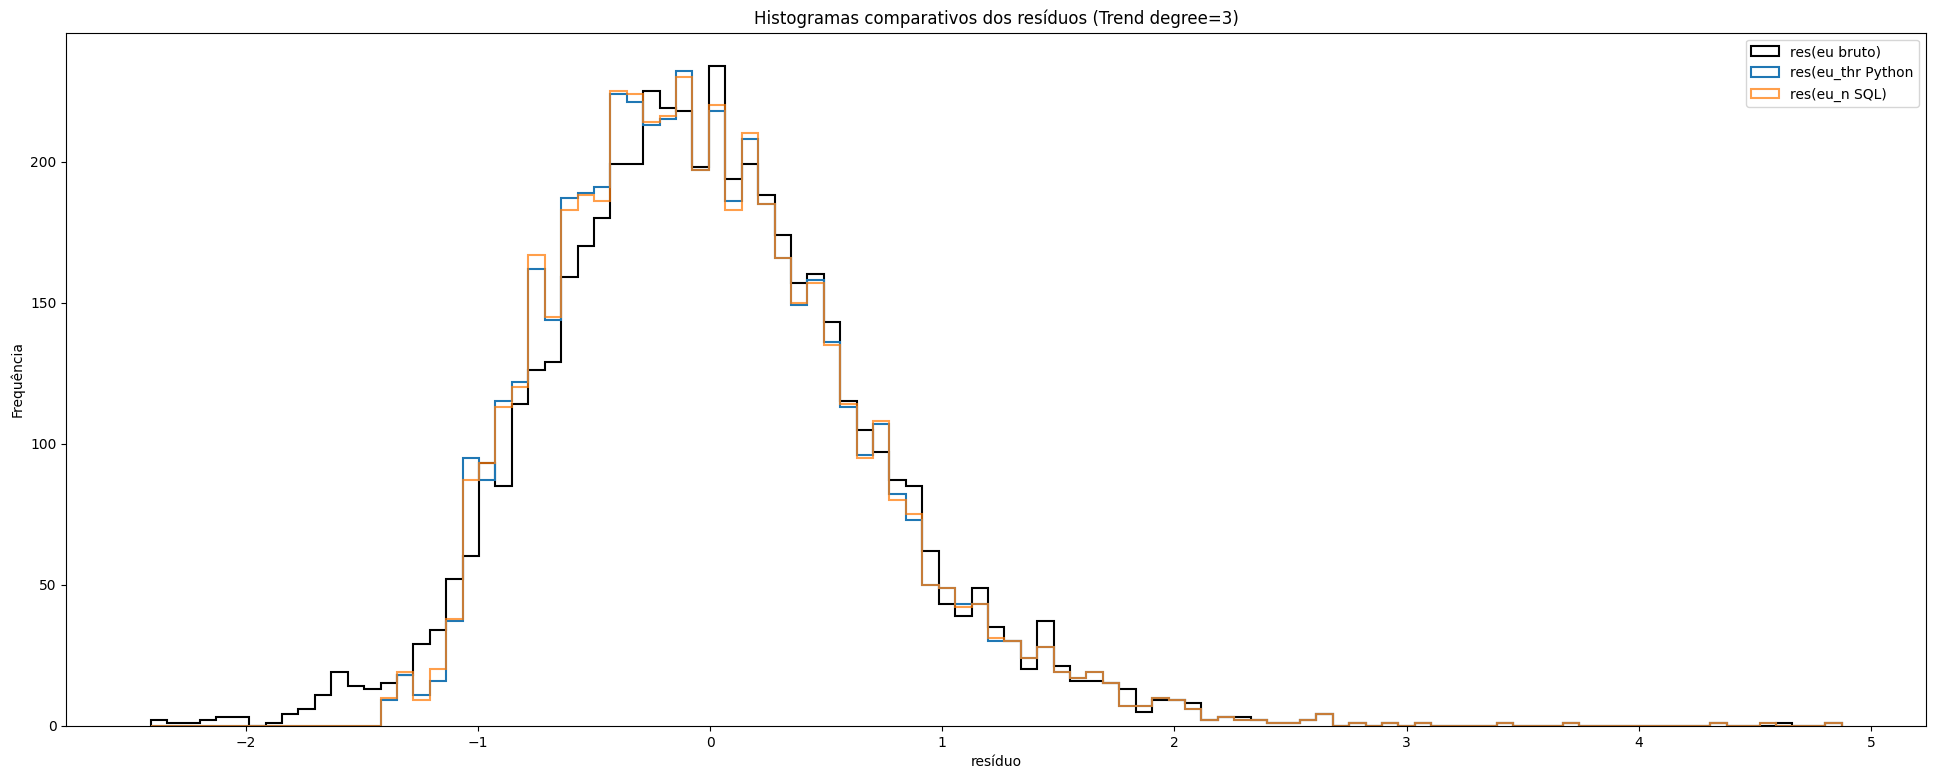

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd

# -------------------------------------------------------
# 1) Calcular Trend e residual para cada versão de eu
# -------------------------------------------------------
vars_eu = ["eu", "eu_thr", "eu_n"]
residuals = {}

for var in vars_eu:
    y = data[var].values

    trend = vd.Trend(degree=3).fit(coordinates, y)
    regional = trend.predict(coordinates)
    resid = y - regional

    residuals[var] = resid
    data[f"{var}_res"] = resid  # opcional, para guardar no DataFrame

# -------------------------------------------------------
# 2) Histograma conjunto dos resíduos das 3 variáveis
# -------------------------------------------------------

# Bins comuns, baseados em todos os resíduos juntos
all_res = np.concatenate([residuals[var] for var in vars_eu])
bins = np.histogram_bin_edges(all_res, bins="auto")

plt.figure(figsize=(24, 9))

plt.hist(
    residuals["eu"],
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label="res(eu bruto)",
    color='black'
)

plt.hist(
    residuals["eu_thr"],
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label="res(eu_thr Python",
    #alpha=0.5,
)

plt.hist(
    residuals["eu_n"],
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label="res(eu_n SQL)",
    alpha=0.75,
)

plt.legend()
plt.xlabel("resíduo")
plt.ylabel("Frequência")
plt.title("Histogramas comparativos dos resíduos (Trend degree=3)")
plt.show()


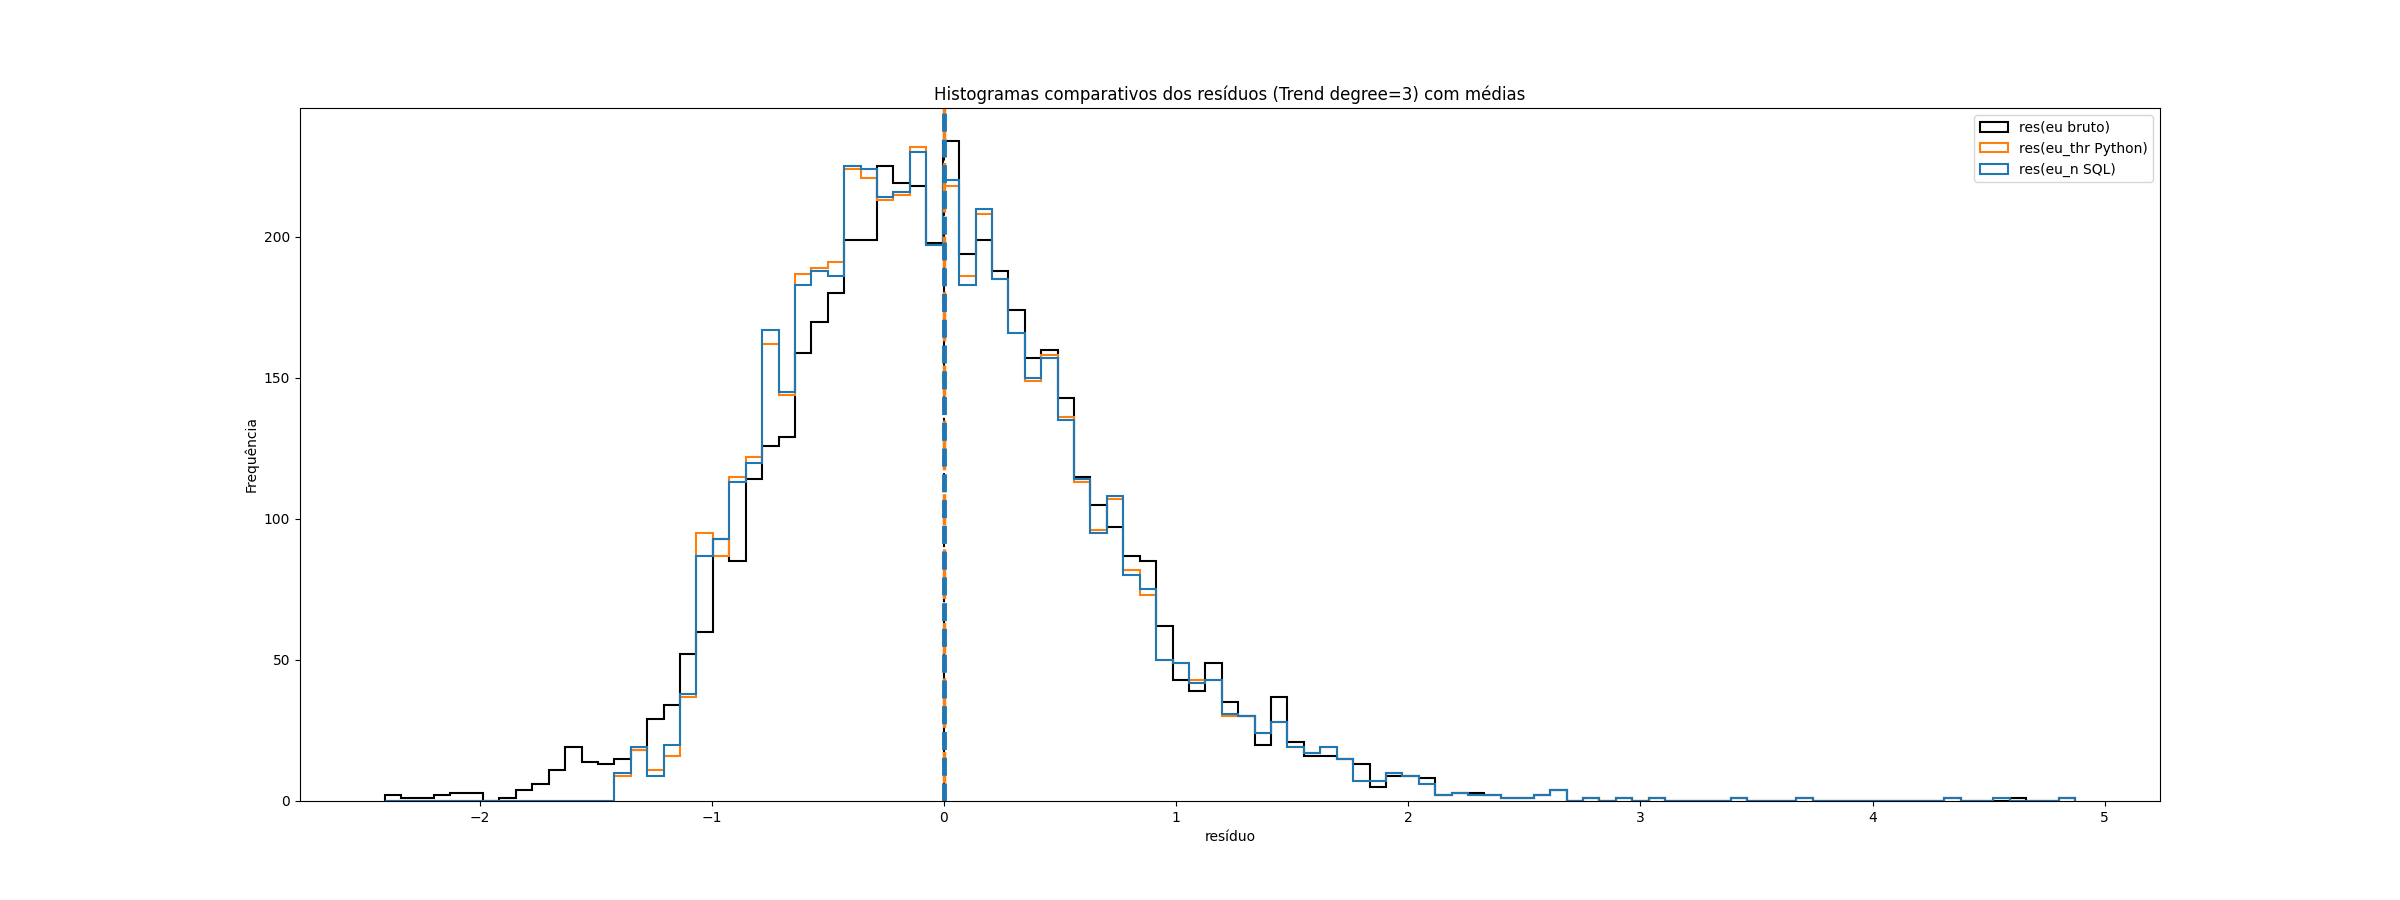

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
%matplotlib widget
# -------------------------------------------------------
# 1) Calcular Trend e residual para cada versão de eu
# -------------------------------------------------------
vars_eu = ["eu", "eu_thr", "eu_n"]
residuals = {}

for var in vars_eu:
    y = data[var].values

    trend = vd.Trend(degree=3).fit(coordinates, y)
    regional = trend.predict(coordinates)
    resid = y - regional

    residuals[var] = resid
    data[f"{var}_res"] = resid  # opcional

# -------------------------------------------------------
# 2) Histograma conjunto dos resíduos das 3 variáveis
# -------------------------------------------------------

all_res = np.concatenate([residuals[var] for var in vars_eu])
bins = np.histogram_bin_edges(all_res, bins="auto")

plt.figure(figsize=(24, 9))

# cores fixas para bater com as linhas de média
cor_eu   = "black"
cor_thr  = "tab:orange"
cor_eu_n = "tab:blue"

# hist eu bruto
plt.hist(
    residuals["eu"],
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label="res(eu bruto)",
    color=cor_eu,
)

# hist eu_thr (Python)
plt.hist(
    residuals["eu_thr"],
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label="res(eu_thr Python)",
    color=cor_thr,
)

# hist eu_n (SQL)
plt.hist(
    residuals["eu_n"],
    bins=bins,
    histtype="step",
    linewidth=1.5,
    label="res(eu_n SQL)",
    color=cor_eu_n,
)

# -------------------------------------------------------
# 3) Linhas de média dos resíduos
# -------------------------------------------------------
mean_eu   = np.nanmean(residuals["eu"])
mean_thr  = np.nanmean(residuals["eu_thr"])
mean_eu_n = np.nanmean(residuals["eu_n"])

plt.axvline(mean_eu,   color=cor_eu,   linestyle="--", linewidth=1.5)
plt.axvline(mean_thr,  color=cor_thr,  linestyle="--", linewidth=2.5)
plt.axvline(mean_eu_n, color=cor_eu_n, linestyle="--", linewidth=3.5)

plt.legend()
plt.xlabel("resíduo")
plt.ylabel("Frequência")
plt.title("Histogramas comparativos dos resíduos (Trend degree=3) com médias")
plt.show()
